#Identidas Diri

Nama: Martza Zhugo Suryandra  
NIM: 250401020020  
Kelas: Data Science IF401  
Dosen Pengampu : Syahid Abdullah, S.Si., M.Kom.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 300

In [8]:
# Pengaturan seed untuk konsistensi hasil
np.random.seed(42)
n = 300

# Generate fitur
pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n)  # 0:SMA, 1:D3, 2:S1
kota = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)

# Generate target dengan noise (error term)
gaji = (3.0 + 2.2 * pengalaman + 1.5 * edu +
        np.where(kota == 'Jakarta', 4.0, 0) +
        np.random.normal(0, 2, n))

df = pd.DataFrame({'pengalaman': pengalaman, 'edu': edu, 'kota': kota, 'gaji': gaji})

print('Dataset Overview:')
display(df.head())
print(df.describe().round(2))

Dataset Overview:


,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265


       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


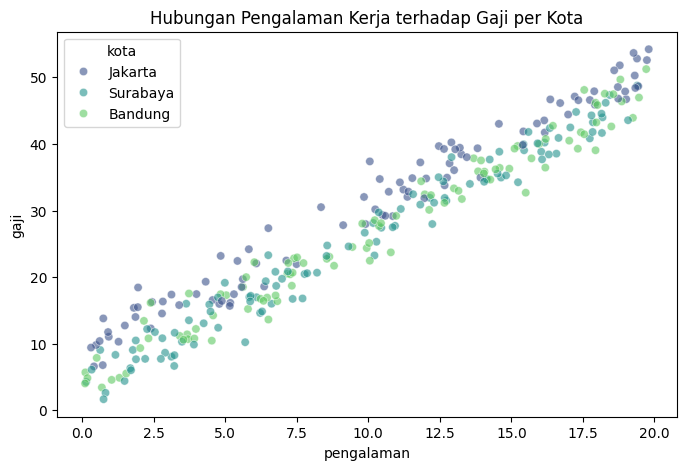

In [9]:
# Visualisasi awal
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='pengalaman', y='gaji', hue='kota', palette='viridis', alpha=0.6)
plt.title('Hubungan Pengalaman Kerja terhadap Gaji per Kota')
plt.show()

In [10]:
# --- Sel 2: Preprocessing ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-Hot Encoding (drop_first=True untuk menghindari multikolinieritas)
df_encoded = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)

X = df_encoded.drop('gaji', axis=1)
y = df_encoded['gaji']

# Split data 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardisasi fitur (PENTING: fit hanya pada train)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Data latih: {X_train.shape[0]} baris, Data uji: {X_test.shape[0]} baris")

Data latih: 240 baris, Data uji: 60 baris


In [11]:
# --- Sel 3: Modeling & Evaluasi ---
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Training
model = LinearRegression()
model.fit(X_train_s, y_train)

# Prediksi
y_pred = model.predict(X_test_s)

# Menampilkan pengaruh fitur
coef_df = pd.DataFrame({'Fitur': X.columns, 'Koefisien': model.coef_.round(3)})
print("\n--- Koefisien Model ---")
print(coef_df.sort_values('Koefisien', ascending=False).to_string(index=False))

# Metrik
print(f"\nMAE  : {mean_absolute_error(y_test, y_pred):.3f} juta")
print(f"RMSE : {root_mean_squared_error(y_test, y_pred):.3f} juta")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")


--- Koefisien Model ---
        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292

MAE  : 1.649 juta
RMSE : 2.123 juta
R²   : 0.9740


In [12]:
# --- Sel 3: Modeling & Evaluasi ---
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Training
model = LinearRegression()
model.fit(X_train_s, y_train)

# Prediksi
y_pred = model.predict(X_test_s)

# Menampilkan pengaruh fitur
coef_df = pd.DataFrame({'Fitur': X.columns, 'Koefisien': model.coef_.round(3)})
print("\n--- Koefisien Model ---")
print(coef_df.sort_values('Koefisien', ascending=False).to_string(index=False))

# Metrik
print(f"\nMAE  : {mean_absolute_error(y_test, y_pred):.3f} juta")
print(f"RMSE : {root_mean_squared_error(y_test, y_pred):.3f} juta")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")


--- Koefisien Model ---
        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292

MAE  : 1.649 juta
RMSE : 2.123 juta
R²   : 0.9740


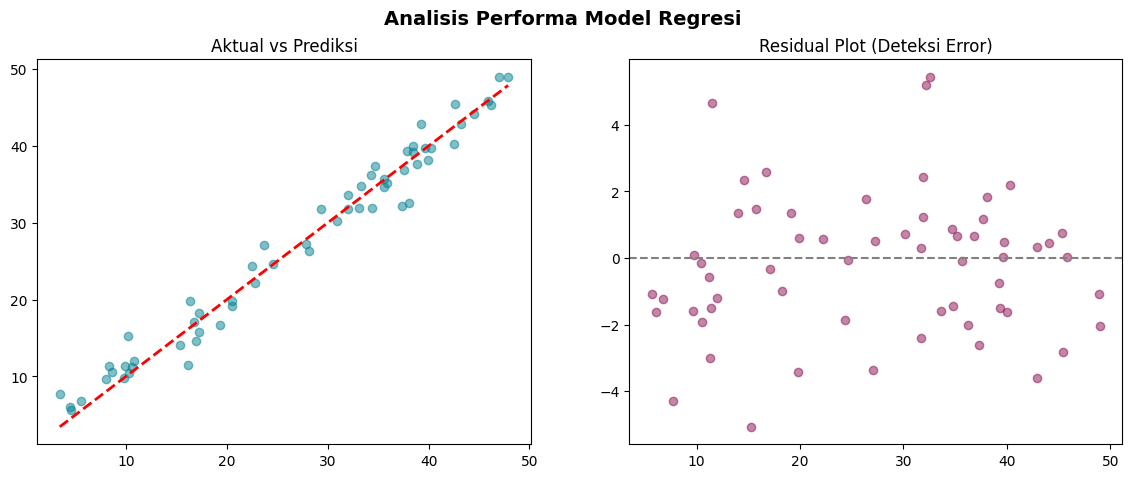

In [13]:
# --- Sel 4: Visualisasi Residual ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Aktual vs Prediksi
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#028090')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Aktual vs Prediksi')

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='#880E4F')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Residual Plot (Deteksi Error)')

plt.suptitle('Analisis Performa Model Regresi', fontsize=14, fontweight='bold')
plt.show()

#Kesimpulan
Pada praktikum ini, saya mempelajari proses pemodelan Machine Learning menggunakan algoritma Regresi Linear dengan library Scikit-Learn. Dataset yang digunakan adalah data sintetis yang merepresentasikan faktor-faktor penentu gaji, seperti pengalaman kerja, tingkat pendidikan, dan lokasi kota.

Dari hasil praktikum, dilakukan berbagai tahapan krusial mulai dari preprocessing data berupa One-Hot Encoding untuk variabel kategorikal, pembagian data menjadi training dan testing set, hingga melakukan feature scaling menggunakan StandardScaler. Selain itu, dilakukan evaluasi model menggunakan metrik MAE, RMSE, serta R^2 untuk mengukur sejauh mana model dapat memprediksi nilai gaji dengan akurat.

Hasil analisis menunjukkan bahwa pengalaman kerja memiliki pengaruh paling dominan terhadap besaran gaji yang diprediksi. Model regresi linear yang dibangun mampu menjelaskan sebagian besar variabilitas data dengan akurasi yang baik, yang didukung oleh sebaran residu yang acak pada residual plot, menandakan bahwa model telah memenuhi asumsi linearitas dengan stabil.

Namun, analisis ini masih menggunakan asumsi hubungan linear sederhana. Terdapat keterbatasan dalam menangkap pola yang lebih kompleks, sehingga diperlukan analisis lanjutan seperti penggunaan algoritma non-linear atau penambahan variabel lain untuk mendapatkan insight dan akurasi prediksi yang lebih mendalam.